# Importando Bibliotecas

In [1]:
import os

try:
    # Configurando diretório de trabalho para 'aulas_teoricas'
    os.chdir("aulas_teoricas")
except FileNotFoundError:
    pass

import logging

# 1. Silencia avisos da camada nativa (C++) do TensorFlow e subprocessos Python
# 0 = todos os logs, 1 = oculta INFO, 2 = oculta INFO e WARNING, 3 = oculta tudo (até ERROR do C++)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["PYTHONWARNINGS"] = "ignore"

# 2. Silencia avisos nativos do Python
import warnings

warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

# 3. Silencia loggers do TensorFlow e Keras (deve vir logo após importar o TF)
import tensorflow as tf

tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
logging.getLogger("tensorflow").setLevel(logging.ERROR)

In [2]:
# Carregamento de dados
from joblib import load, dump

# Processamento de dados
import pandas as pd
from util import utils as ut
import numpy as np

# Estatística
from scipy.stats import chi2_contingency
from scipy.stats import ks_2samp
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import levene

# Graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Classificador
from src.regression import Regression

# Importando Dados

In [3]:
# Verificando os arquivos no diretório 'data/df_estruturada'
os.listdir("./data/df_estruturada")

['08_aula_09_X_test',
 '08_aula_09_X_train',
 '08_aula_09_X_valid',
 '08_aula_09_y_test',
 '08_aula_09_y_train',
 '08_aula_09_y_valid',
 '__init__.py']

In [4]:
# Importando os dados de treino
df_train = pd.concat(
    [
        load("./data/df_estruturada/08_aula_09_X_train"),
        load("./data/df_estruturada/08_aula_09_y_train"),
    ],
    axis=1,
)
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Baixo,imunodeficiencia
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Baixo,imunodeficiencia
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Alto,leucemia
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Baixo,imunodeficiencia
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Alto,leucemia


In [5]:
# Importando os dados de treino
df_valid = pd.concat(
    [
        load("./data/df_estruturada/08_aula_09_X_valid"),
        load("./data/df_estruturada/08_aula_09_y_valid"),
    ],
    axis=1,
)
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Baixo,imunodeficiencia
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Alto,leucemia
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Alto,cancer
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Alto,cancer
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Alto,cancer


In [6]:
# Importando os dados de treino
df_test = pd.concat(
    [
        load("./data/df_estruturada/08_aula_09_X_test"),
        load("./data/df_estruturada/08_aula_09_y_test"),
    ],
    axis=1,
)
df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Alto,cancer
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Alto,leucemia
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Alto,cancer
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Alto,cancer
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Baixo,imunodeficiencia


# Validação cruzada e busca de hiperparâmetros

## Treino

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
feature_selection__k -> all
regressor__fit_intercept -> True
regressor__positive -> False
var_threshold__threshold -> 0.0001
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__IgM_Baixo
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True   

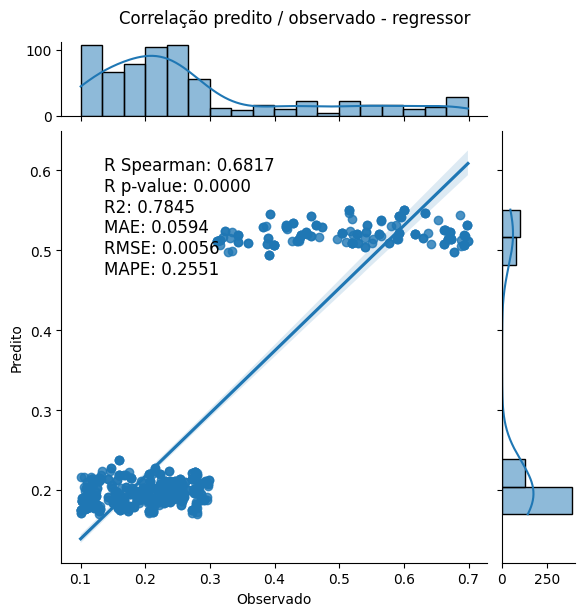

In [7]:
regressor = Regression(df=df_train)

metricas_regr, pred_regr = regressor.regress(modelo="regressor")

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
feature_selection__k -> all
svm__C -> 0.1
svm__epsilon -> 0.01
svm__kernel -> linear
var_threshold__threshold -> 0.0001
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__IgM_Baixo
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True        

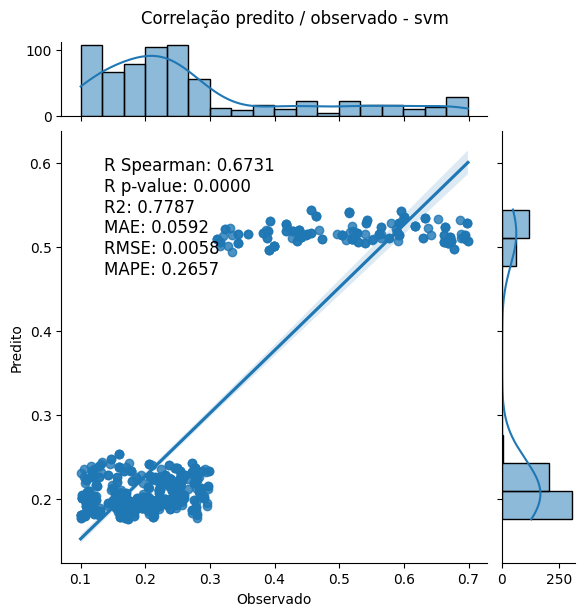

In [8]:
metricas_svm, pred_svm = regressor.regress(modelo="svm")

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
feature_selection__k -> all
nb__alpha_1 -> 0.0001
nb__lambda_1 -> 1e-06
nb__max_iter -> 100
var_threshold__threshold -> 0.0001
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__IgM_Baixo
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True 

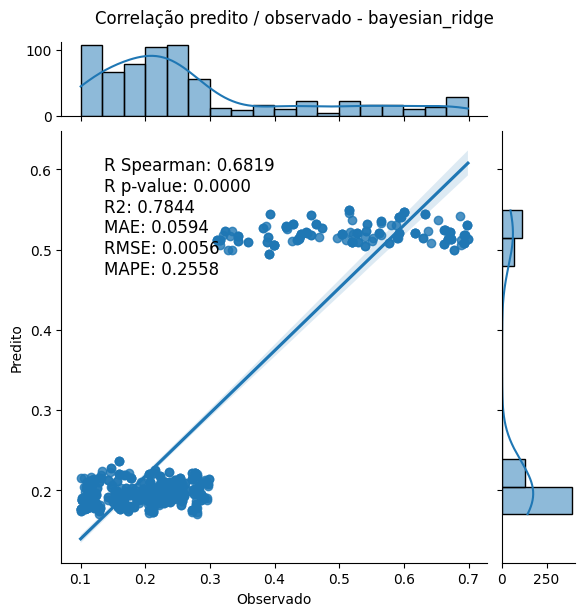

In [9]:
metricas_nb, pred_nb = regressor.regress(modelo="bayesian_ridge")

O cálculo do volume de treinos atual é:$$\underbrace{3}_{\text{threshold}} \times \underbrace{3}_{\text{k}} \times \underbrace{3}_{\text{optimizer}} \times \underbrace{2}_{\text{epochs}} \times \underbrace{3}_{\text{batch\_size}} \times \underbrace{4}_{\text{activation1}} \times \underbrace{4}_{\text{activation2}} = 2.592 \text{ combinações}$$Multiplicado pelos $5$ folds do Cross-Validation: $2.592 \times 5 = 12.960$ modelos sendo ajustados.

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
var_threshold__threshold -> 0.01
nn__optimizer -> RMSprop
nn__epochs -> 100
nn__batch_size -> 16
nn__activation2 -> tanh
nn__activation1 -> softmax
feature_selection__k -> all
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__IgM_Baixo
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               Tru

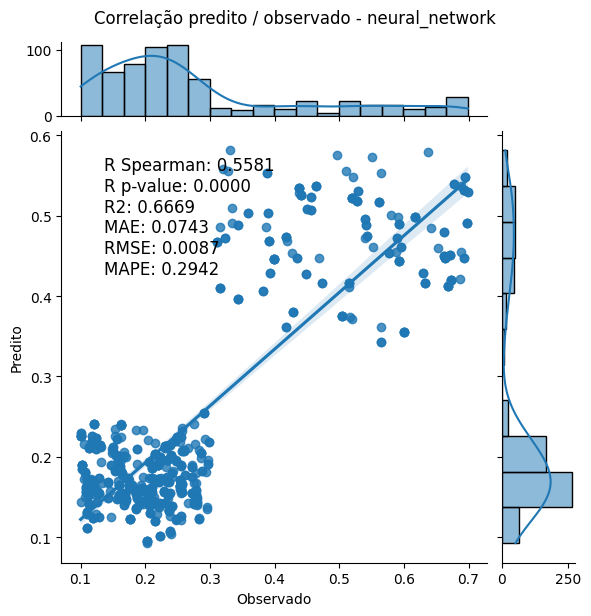

In [10]:
metricas_nn, pred_nn = regressor.regress(modelo="neural_network", n_iter_search=5)

In [11]:
try:
    metricas_estr, pred_estr = regressor.regress(modelo="Estrela")
except ValueError as e:
    print(e)

Modelo inválido: Estrela. Escolha 'regressor', 'svm', 'bayesian_ridge' ou 'neural_network'.


In [12]:
algoritmo_1 = "Multiple Linear Regression"
algoritmo_2 = "Suport Vector Machine"
algoritmo_3 = "Nayve Bayes"
algoritmo_4 = "Neural Network"

# Organizando as métricas de treinamento
df_metricas_train = pd.concat(
    [
        metricas_regr.T.copy(),
        metricas_svm.T.copy(),
        metricas_nb.T.copy(),
        metricas_nn.T.copy(),
    ]
)
df_metricas_train.reset_index(inplace=True)
df_metricas_train["modelo"] = (
    [algoritmo_1] * 6 + [algoritmo_2] * 6 + [algoritmo_3] * 6 + [algoritmo_4] * 6
)
df_metricas_train.rename(columns={"index": "metricas", 0: "valores"}, inplace=True)
df_metricas_train.head()

,metricas,valores,modelo
0,R Spearman,0.6817,Multiple Linear Regression
1,R p-value,0.0000,Multiple Linear Regression
2,R2,0.7845,Multiple Linear Regression
3,MAE,0.0594,Multiple Linear Regression
4,RMSE,0.0056,Multiple Linear Regression


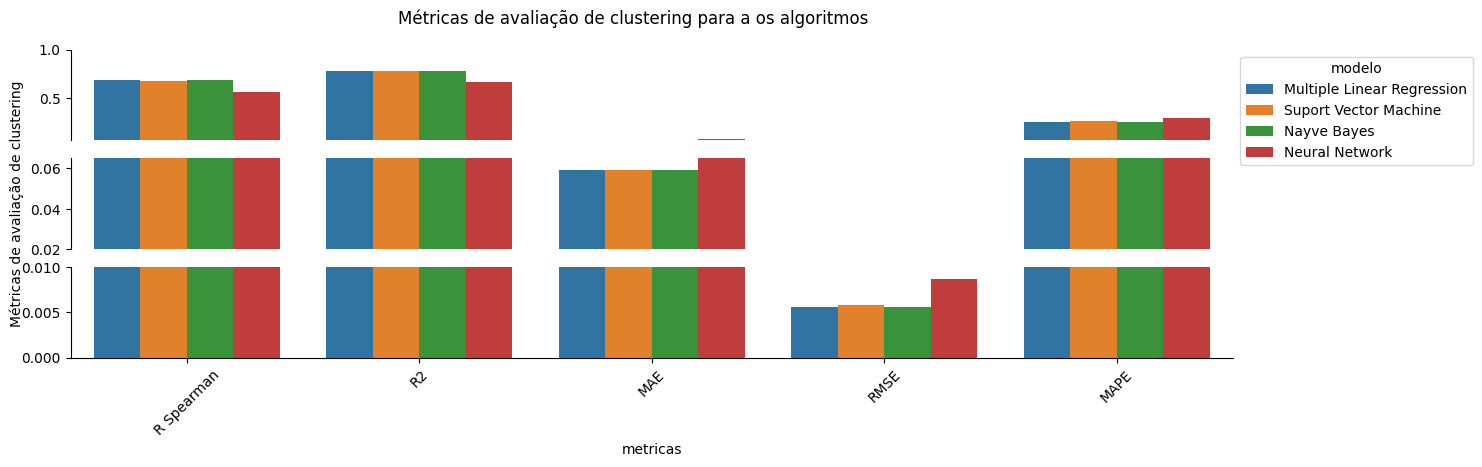

In [13]:
# Grafico comparativo das métricas de avaliação de clustering para os três
# algoritmos, com multi-index, e calculando a mediana das métricas
fig, ax = plt.subplots(3, 1, figsize=(15, 4))
plt.suptitle("Métricas de avaliação de clustering para a os algoritmos")
p = sns.barplot(
    x="metricas",
    y="valores",
    hue="modelo",
    data=df_metricas_train[df_metricas_train["metricas"] != "R p-value"],
    ax=ax[0],
)
p.set_ylim(0.065, 1)
p.set(xlabel=None, ylabel=None)
p.set_xticks([])
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(1, 1))
p.spines["bottom"].set_visible(False)
p.spines[["top", "right"]].set_visible(False)

t = sns.barplot(
    x="metricas",
    y="valores",
    hue="modelo",
    data=df_metricas_train[df_metricas_train["metricas"] != "R p-value"],
    ax=ax[1],
)
t.set_ylim(0.02, 0.065)
t.set(xlabel=None)
t.set_xticks([])
t.spines["bottom"].set_visible(False)
t.spines[["top", "right"]].set_visible(False)
t.get_legend().remove()
t.set_ylabel("Métricas de avaliação de clustering", loc="center")

q = sns.barplot(
    x="metricas",
    y="valores",
    hue="modelo",
    data=df_metricas_train[df_metricas_train["metricas"] != "R p-value"],
    ax=ax[2],
)
q.set(ylabel=None)
q.set_ylim(0, 0.01)
q.get_legend().remove()
q.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45)

plt.show()

In [14]:
df_train[algoritmo_1] = pred_regr.copy()
df_train[algoritmo_2] = pred_svm.copy()
df_train[algoritmo_3] = pred_nb.copy()
df_train[algoritmo_4] = pred_nn.copy()

df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Baixo,imunodeficiencia,0.212639,0.226395,0.211931,0.146816
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Baixo,imunodeficiencia,0.222520,0.237181,0.221760,0.151572
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Alto,leucemia,0.199940,0.203320,0.199446,0.144705
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Baixo,imunodeficiencia,0.213565,0.233762,0.212749,0.158711
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Alto,leucemia,0.177484,0.192359,0.178101,0.171980


## Validação

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
feature_selection__k -> all
regressor__fit_intercept -> True
regressor__positive -> False
var_threshold__threshold -> 0.0001
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__IgM_Baixo
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True   

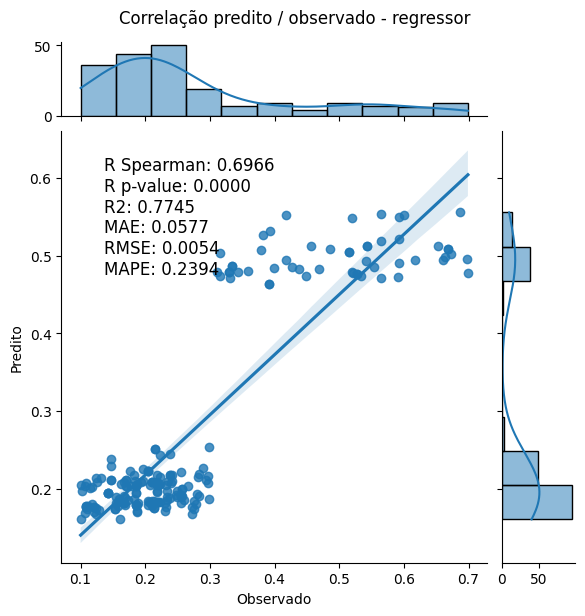

In [15]:
regressor = Regression(df=df_valid)

metricas_regr, pred_regr = regressor.regress(modelo="regressor")

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
feature_selection__k -> all
svm__C -> 1
svm__epsilon -> 0.01
svm__kernel -> linear
var_threshold__threshold -> 0.0001
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__IgM_Baixo
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True          

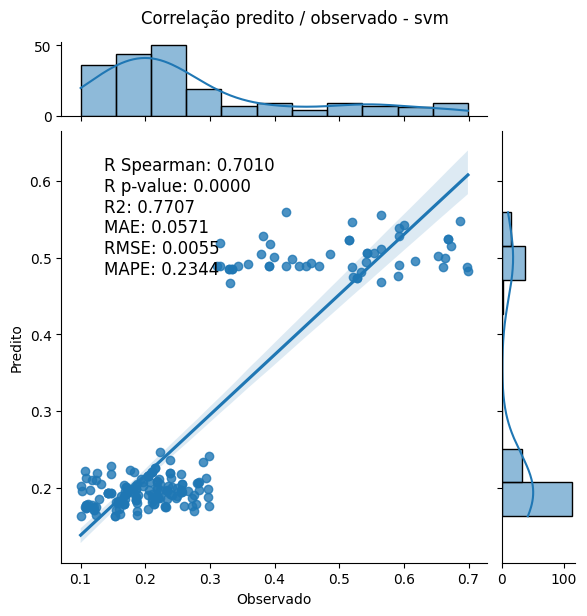

In [16]:
metricas_svm, pred_svm = regressor.regress(modelo="svm")

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
feature_selection__k -> all
nb__alpha_1 -> 0.0001
nb__lambda_1 -> 1e-06
nb__max_iter -> 100
var_threshold__threshold -> 0.0001
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__IgM_Baixo
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True 

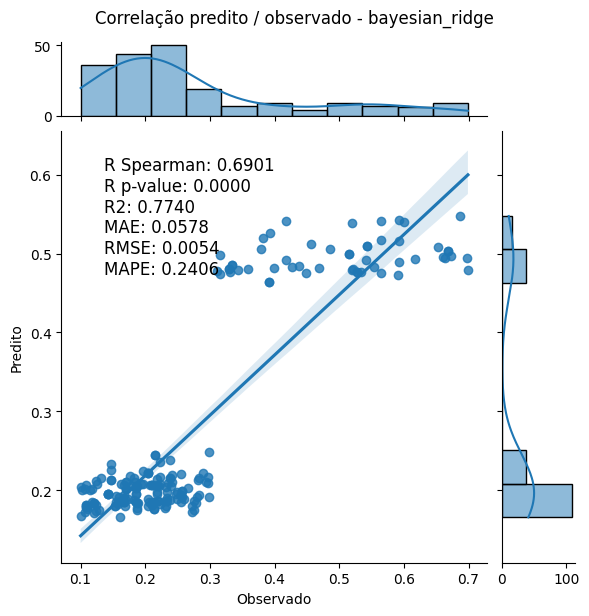

In [17]:
metricas_nb, pred_nb = regressor.regress(modelo="bayesian_ridge")

O cálculo do volume de treinos atual é:$$\underbrace{3}_{\text{threshold}} \times \underbrace{3}_{\text{k}} \times \underbrace{3}_{\text{optimizer}} \times \underbrace{2}_{\text{epochs}} \times \underbrace{3}_{\text{batch\_size}} \times \underbrace{4}_{\text{activation1}} \times \underbrace{4}_{\text{activation2}} = 2.592 \text{ combinações}$$Multiplicado pelos $5$ folds do Cross-Validation: $2.592 \times 5 = 12.960$ modelos sendo ajustados.

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
var_threshold__threshold -> 0.01
nn__optimizer -> Adam
nn__epochs -> 100
nn__batch_size -> 16
nn__activation2 -> sigmoid
nn__activation1 -> relu
feature_selection__k -> 2
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    2

--- Lista das Variáveis Selecionadas ---
1. num__PPD_log
2. num__correlatas

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True              False
                  num__CD3_2              True              False
                    num__CD8              True              False
                num__PPD_log              True               True
             num__correlatas              True               True
      

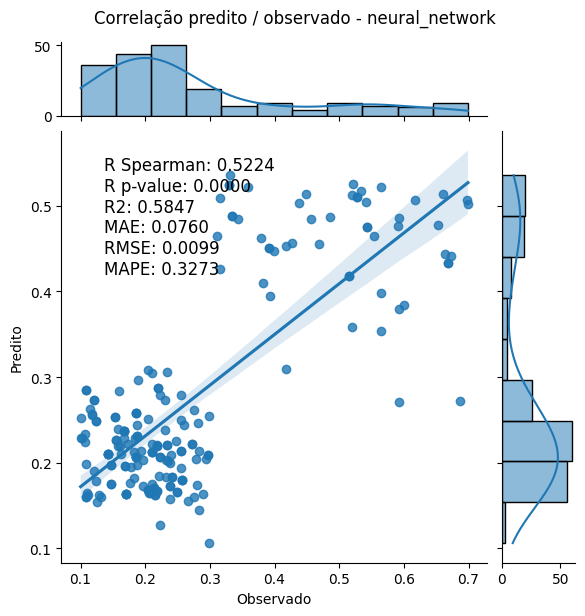

In [18]:
metricas_nn, pred_nn = regressor.regress(modelo="neural_network", n_iter_search=5)

In [19]:
try:
    metricas_estr, pred_estr = regressor.regress(modelo="Estrela")
except ValueError as e:
    print(e)

Modelo inválido: Estrela. Escolha 'regressor', 'svm', 'bayesian_ridge' ou 'neural_network'.


In [20]:
# Organizando as métricas de treinamento
df_metricas_valid = pd.concat(
    [
        metricas_regr.T.copy(),
        metricas_svm.T.copy(),
        metricas_nb.T.copy(),
        metricas_nn.T.copy(),
    ]
)
df_metricas_valid.reset_index(inplace=True)
df_metricas_valid["modelo"] = (
    [algoritmo_1] * 6 + [algoritmo_2] * 6 + [algoritmo_3] * 6 + [algoritmo_4] * 6
)
df_metricas_valid.rename(columns={"index": "metricas", 0: "valores"}, inplace=True)
df_metricas_valid.head()

,metricas,valores,modelo
0,R Spearman,0.6966,Multiple Linear Regression
1,R p-value,0.0000,Multiple Linear Regression
2,R2,0.7745,Multiple Linear Regression
3,MAE,0.0577,Multiple Linear Regression
4,RMSE,0.0054,Multiple Linear Regression


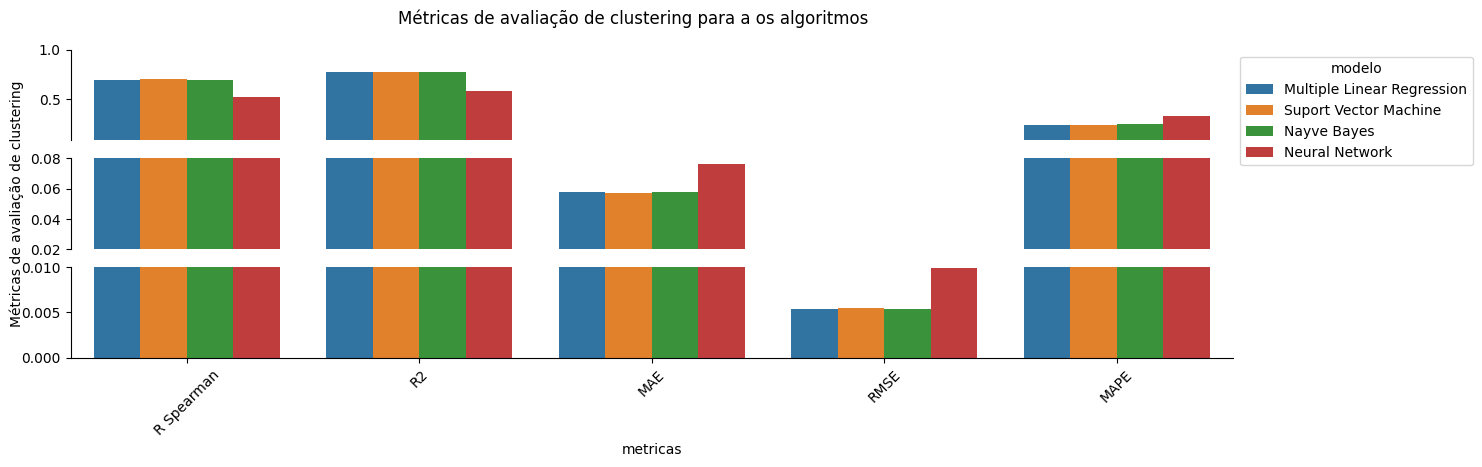

In [21]:
# Grafico comparativo das métricas de avaliação de clustering para os três
# algoritmos, com multi-index, e calculando a mediana das métricas
fig, ax = plt.subplots(3, 1, figsize=(15, 4))
plt.suptitle("Métricas de avaliação de clustering para a os algoritmos")
p = sns.barplot(
    x="metricas",
    y="valores",
    hue="modelo",
    data=df_metricas_valid[df_metricas_valid["metricas"] != "R p-value"],
    ax=ax[0],
)
p.set_ylim(0.08, 1)
p.set(xlabel=None, ylabel=None)
p.set_xticks([])
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(1, 1))
p.spines["bottom"].set_visible(False)
p.spines[["top", "right"]].set_visible(False)

t = sns.barplot(
    x="metricas",
    y="valores",
    hue="modelo",
    data=df_metricas_valid[df_metricas_valid["metricas"] != "R p-value"],
    ax=ax[1],
)
t.set_ylim(0.02, 0.08)
t.set(xlabel=None)
t.set_xticks([])
t.spines["bottom"].set_visible(False)
t.spines[["top", "right"]].set_visible(False)
t.get_legend().remove()
t.set_ylabel("Métricas de avaliação de clustering", loc="center")

q = sns.barplot(
    x="metricas",
    y="valores",
    hue="modelo",
    data=df_metricas_valid[df_metricas_valid["metricas"] != "R p-value"],
    ax=ax[2],
)
q.set(ylabel=None)
q.set_ylim(0, 0.01)
q.get_legend().remove()
q.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45)

plt.show()

In [22]:
df_valid[algoritmo_1] = pred_regr.copy()
df_valid[algoritmo_2] = pred_svm.copy()
df_valid[algoritmo_3] = pred_nb.copy()
df_valid[algoritmo_4] = pred_nn.copy()

df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Baixo,imunodeficiencia,0.179415,0.183592,0.184897,0.258323
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Alto,leucemia,0.161601,0.165337,0.165370,0.219533
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Alto,cancer,0.237762,0.227987,0.233136,0.174639
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Alto,cancer,0.189585,0.181273,0.192926,0.226852
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Alto,cancer,0.223239,0.214699,0.221535,0.167668


## Teste

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
feature_selection__k -> all
regressor__fit_intercept -> True
regressor__positive -> False
var_threshold__threshold -> 0.0001
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__IgM_Baixo
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True   

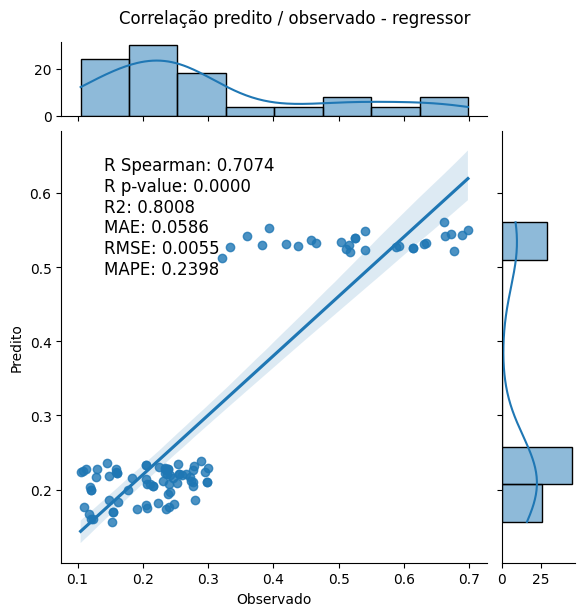

In [23]:
regressor = Regression(df=df_test)

metricas_regr, pred_regr = regressor.regress(modelo="regressor")

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
feature_selection__k -> all
svm__C -> 10
svm__epsilon -> 0.1
svm__kernel -> rbf
var_threshold__threshold -> 0.0001
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__IgM_Baixo
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True             

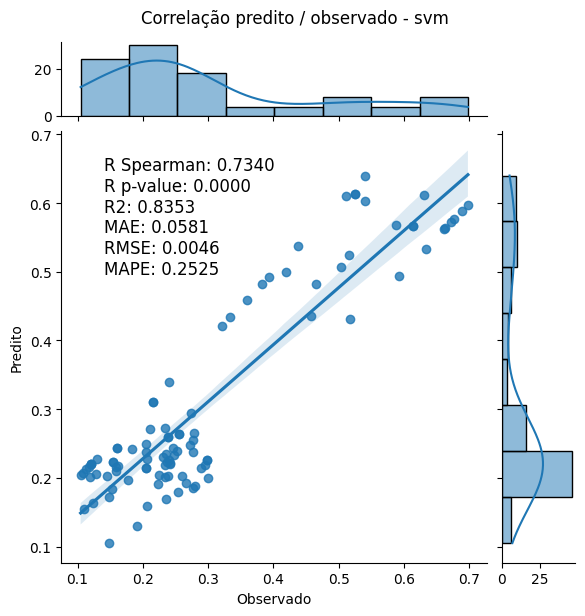

In [24]:
metricas_svm, pred_svm = regressor.regress(modelo="svm")

Iniciando o Grid Search com Cross Validation...
Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
feature_selection__k -> all
nb__alpha_1 -> 0.0001
nb__lambda_1 -> 1e-06
nb__max_iter -> 100
var_threshold__threshold -> 0.0001
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__IgM_Baixo
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True 

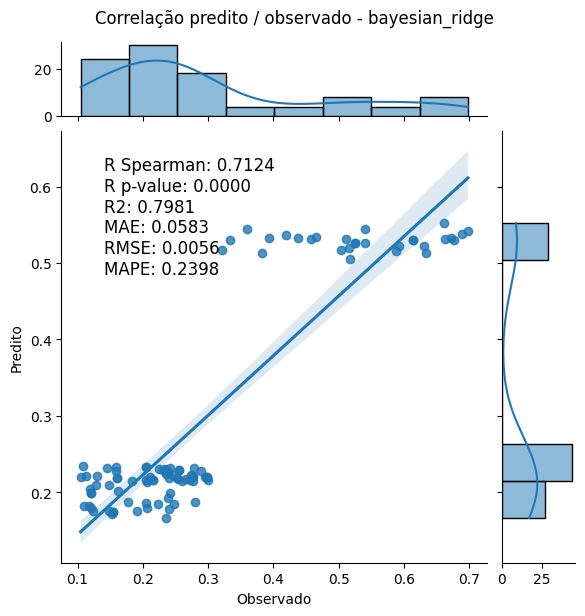

In [25]:
metricas_nb, pred_nb = regressor.regress(modelo="bayesian_ridge")

O cálculo do volume de treinos atual é:$$\underbrace{3}_{\text{threshold}} \times \underbrace{3}_{\text{k}} \times \underbrace{3}_{\text{optimizer}} \times \underbrace{2}_{\text{epochs}} \times \underbrace{3}_{\text{batch\_size}} \times \underbrace{4}_{\text{activation1}} \times \underbrace{4}_{\text{activation2}} = 2.592 \text{ combinações}$$Multiplicado pelos $5$ folds do Cross-Validation: $2.592 \times 5 = 12.960$ modelos sendo ajustados.

Iniciando o Grid Search com Cross Validation...


Grid Search concluído.
Melhores parâmetros encontrados:
------------------
-=< Dicionário >=-
------------------
var_threshold__threshold -> 0.01
nn__optimizer -> RMSprop
nn__epochs -> 100
nn__batch_size -> 32
nn__activation2 -> tanh
nn__activation1 -> relu
feature_selection__k -> 1
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    1

--- Lista das Variáveis Selecionadas ---
1. num__PPD_log

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True              False
                  num__CD3_2              True              False
                    num__CD8              True              False
                num__PPD_log              True               True
             num__correlatas              True              False
              cat__IgM_Baixo              True              False
       

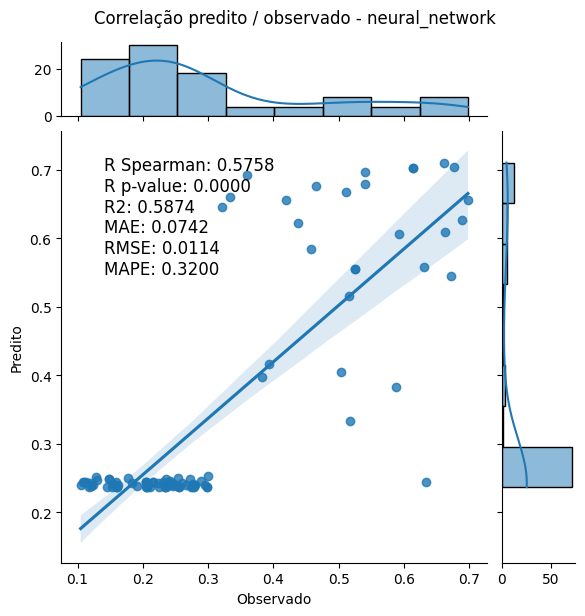

In [26]:
metricas_nn, pred_nn = regressor.regress(modelo="neural_network", n_iter_search=5)

In [27]:
# Organizando as métricas de treinamento
df_metricas_test = pd.concat(
    [
        metricas_regr.T.copy(),
        metricas_svm.T.copy(),
        metricas_nb.T.copy(),
        metricas_nn.T.copy(),
    ]
)
df_metricas_test.reset_index(inplace=True)
df_metricas_test["modelo"] = (
    [algoritmo_1] * 6 + [algoritmo_2] * 6 + [algoritmo_3] * 6 + [algoritmo_4] * 6
)
df_metricas_test.rename(columns={"index": "metricas", 0: "valores"}, inplace=True)
df_metricas_test.head()

,metricas,valores,modelo
0,R Spearman,0.7074,Multiple Linear Regression
1,R p-value,0.0000,Multiple Linear Regression
2,R2,0.8008,Multiple Linear Regression
3,MAE,0.0586,Multiple Linear Regression
4,RMSE,0.0055,Multiple Linear Regression


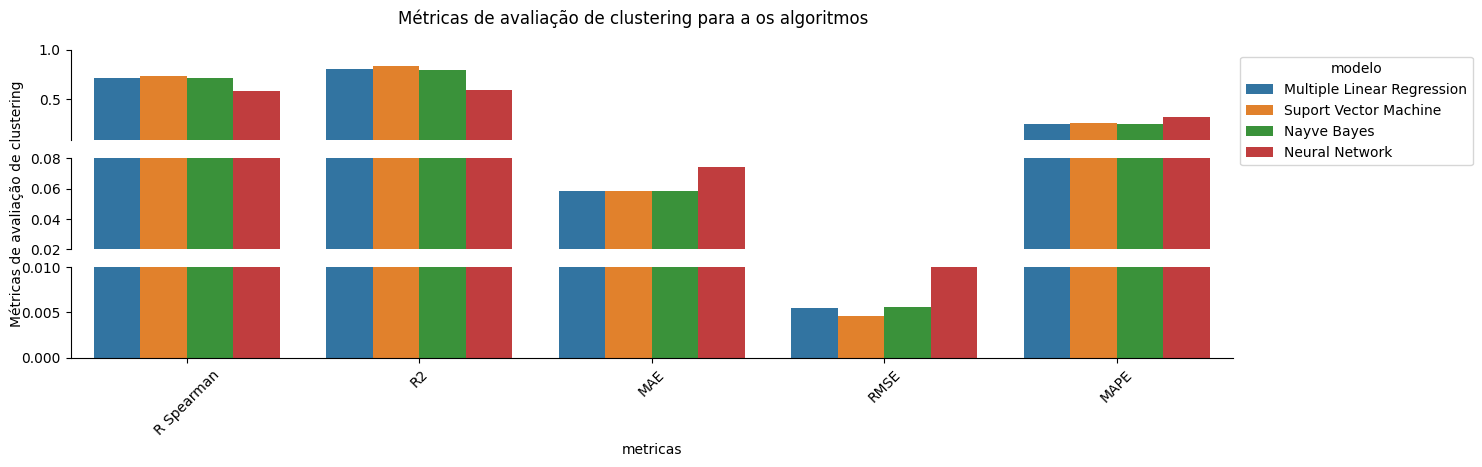

In [28]:
# Grafico comparativo das métricas de avaliação de clustering para os três
# algoritmos, com multi-index, e calculando a mediana das métricas
fig, ax = plt.subplots(3, 1, figsize=(15, 4))
plt.suptitle("Métricas de avaliação de clustering para a os algoritmos")
p = sns.barplot(
    x="metricas",
    y="valores",
    hue="modelo",
    data=df_metricas_test[df_metricas_test["metricas"] != "R p-value"],
    ax=ax[0],
)
p.set_ylim(0.08, 1)
p.set(xlabel=None, ylabel=None)
p.set_xticks([])
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(1, 1))
p.spines["bottom"].set_visible(False)
p.spines[["top", "right"]].set_visible(False)

t = sns.barplot(
    x="metricas",
    y="valores",
    hue="modelo",
    data=df_metricas_test[df_metricas_test["metricas"] != "R p-value"],
    ax=ax[1],
)
t.set_ylim(0.02, 0.08)
t.set(xlabel=None)
t.set_xticks([])
t.spines["bottom"].set_visible(False)
t.spines[["top", "right"]].set_visible(False)
t.get_legend().remove()
t.set_ylabel("Métricas de avaliação de clustering", loc="center")

q = sns.barplot(
    x="metricas",
    y="valores",
    hue="modelo",
    data=df_metricas_test[df_metricas_test["metricas"] != "R p-value"],
    ax=ax[2],
)
q.set(ylabel=None)
q.set_ylim(0, 0.01)
q.get_legend().remove()
q.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45)

plt.show()

In [29]:
df_test[algoritmo_1] = pred_regr.copy()
df_test[algoritmo_2] = pred_svm.copy()
df_test[algoritmo_3] = pred_nb.copy()
df_test[algoritmo_4] = pred_nn.copy()

df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Alto,cancer,0.227496,0.259514,0.226350,0.240134
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Alto,leucemia,0.177090,0.226466,0.178149,0.240572
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Alto,cancer,0.211997,0.294908,0.222489,0.236782
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Alto,cancer,0.214366,0.248942,0.215557,0.243145
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Baixo,imunodeficiencia,0.210735,0.225542,0.219586,0.236921


# Avalia Modelos

In [30]:
dump(df_train, "./data/08_aula_09_df_train_resultados_regression")
df_train = load("./data/08_aula_09_df_train_resultados_regression")

dump(df_valid, "./data/08_aula_09_df_valid_resultados_regression")
df_valid = load("./data/08_aula_09_df_valid_resultados_regression")

dump(df_test, "./data/08_aula_09_df_test_resultados_regression")
df_test = load("./data/08_aula_09_df_test_resultados_regression")

In [31]:
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Baixo,imunodeficiencia,0.212639,0.226395,0.211931,0.146816
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Baixo,imunodeficiencia,0.222520,0.237181,0.221760,0.151572
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Alto,leucemia,0.199940,0.203320,0.199446,0.144705
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Baixo,imunodeficiencia,0.213565,0.233762,0.212749,0.158711
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Alto,leucemia,0.177484,0.192359,0.178101,0.171980


In [32]:
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Baixo,imunodeficiencia,0.179415,0.183592,0.184897,0.258323
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Alto,leucemia,0.161601,0.165337,0.165370,0.219533
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Alto,cancer,0.237762,0.227987,0.233136,0.174639
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Alto,cancer,0.189585,0.181273,0.192926,0.226852
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Alto,cancer,0.223239,0.214699,0.221535,0.167668


In [33]:
df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,IgM,classe,Multiple Linear Regression,Suport Vector Machine,Nayve Bayes,Neural Network
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Alto,cancer,0.227496,0.259514,0.226350,0.240134
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Alto,leucemia,0.177090,0.226466,0.178149,0.240572
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Alto,cancer,0.211997,0.294908,0.222489,0.236782
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Alto,cancer,0.214366,0.248942,0.215557,0.243145
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Baixo,imunodeficiencia,0.210735,0.225542,0.219586,0.236921


In [34]:
def testar_hipotese(y_pred_treino: pd.Series, y_pred_teste: pd.Series) -> None:
    """
    Testa a hipótese de que a distribuição das classes no treino e no teste é estatisticamente igual (homogênea)
    ou diferente (heterogênea) usando o teste Qui-Quadrado.

    Parâmetros:
        y_pred_treino : pd.Series
            Série contendo as previsões do conjunto de treino.
        y_pred_teste : pd.Series
            Série contendo as previsões do conjunto de teste.
    Retorna:
        None
    """

    ks_stat, p_v_ks = ks_2samp(y_pred_treino, y_pred_teste)

    # 1. Teste T de Welch (para médias, assumindo variâncias potencialmente diferentes)
    t_stat, p_val_t = ttest_ind(y_pred_treino, y_pred_teste, equal_var=False)

    # 2. Teste U de Mann-Whitney (para medianas/posição, não-paramétrico)
    u_stat, p_val_u = mannwhitneyu(y_pred_treino, y_pred_teste, alternative="two-sided")

    # 3. Teste de Levene (para variâncias/dispersão)
    w_stat, p_val_levene = levene(y_pred_treino, y_pred_teste)

    # Função auxiliar para imprimir resultados
    def interpretar(nome_teste, p_valor, stat, alfa=0.05):
        resultado = (
            "DIFERENTES (Rejeita H0)"
            if p_valor < alfa
            else "IGUAIS (Falha ao rejeitar H0)"
        )
        print(
            f"{nome_teste:<25} | estatística: {stat:.4f} | p-valor: {p_valor:.4f} | Conclusão: {resultado}"
        )

    print("=== Resultados dos Testes Estatísticos ===\n")
    interpretar("Teste Kolmogorov-Smirnov", p_v_ks, ks_stat)
    interpretar("Teste T (Médias)", p_val_t, t_stat)
    interpretar("Mann-Whitney (Medianas)", p_val_u, u_stat)
    interpretar("Levene (Variâncias)", p_val_levene, w_stat)

    return None

In [35]:
c = -4
print(f"\n\nTestando a hipótese para o modelo: {df_train.columns[c]}")

testar_hipotese(
    y_pred_treino=df_train[df_train.columns[c]],
    y_pred_teste=df_test[df_test.columns[c]],
)



Testando a hipótese para o modelo: Multiple Linear Regression
=== Resultados dos Testes Estatísticos ===

Teste Kolmogorov-Smirnov  | estatística: 0.3414 | p-valor: 0.0000 | Conclusão: DIFERENTES (Rejeita H0)
Teste T (Médias)          | estatística: -1.4155 | p-valor: 0.1594 | Conclusão: IGUAIS (Falha ao rejeitar H0)
Mann-Whitney (Medianas)   | estatística: 24970.0000 | p-valor: 0.0000 | Conclusão: DIFERENTES (Rejeita H0)
Levene (Variâncias)       | estatística: 0.6600 | p-valor: 0.4168 | Conclusão: IGUAIS (Falha ao rejeitar H0)


In [36]:
c += 1
print(f"\n\nTestando a hipótese para o modelo: {df_train.columns[c]}")
testar_hipotese(
    y_pred_treino=df_train[df_train.columns[c]],
    y_pred_teste=df_test[df_test.columns[c]],
)



Testando a hipótese para o modelo: Suport Vector Machine
=== Resultados dos Testes Estatísticos ===

Teste Kolmogorov-Smirnov  | estatística: 0.2286 | p-valor: 0.0002 | Conclusão: DIFERENTES (Rejeita H0)
Teste T (Médias)          | estatística: -1.6211 | p-valor: 0.1076 | Conclusão: IGUAIS (Falha ao rejeitar H0)
Mann-Whitney (Medianas)   | estatística: 27648.0000 | p-valor: 0.0007 | Conclusão: DIFERENTES (Rejeita H0)
Levene (Variâncias)       | estatística: 2.0403 | p-valor: 0.1536 | Conclusão: IGUAIS (Falha ao rejeitar H0)


In [37]:
c += 1
print(f"\n\nTestando a hipótese para o modelo: {df_train.columns[c]}")

testar_hipotese(
    y_pred_treino=df_train[df_train.columns[c]],
    y_pred_teste=df_test[df_test.columns[c]],
)



Testando a hipótese para o modelo: Nayve Bayes
=== Resultados dos Testes Estatísticos ===

Teste Kolmogorov-Smirnov  | estatística: 0.4100 | p-valor: 0.0000 | Conclusão: DIFERENTES (Rejeita H0)
Teste T (Médias)          | estatística: -1.4457 | p-valor: 0.1507 | Conclusão: IGUAIS (Falha ao rejeitar H0)
Mann-Whitney (Medianas)   | estatística: 24559.0000 | p-valor: 0.0000 | Conclusão: DIFERENTES (Rejeita H0)
Levene (Variâncias)       | estatística: 0.4012 | p-valor: 0.5266 | Conclusão: IGUAIS (Falha ao rejeitar H0)


In [38]:
c += 1
print(f"\n\nTestando a hipótese para o modelo: {df_train.columns[c]}")

testar_hipotese(
    y_pred_treino=df_train[df_train.columns[c]],
    y_pred_teste=df_test[df_test.columns[c]],
)



Testando a hipótese para o modelo: Neural Network
=== Resultados dos Testes Estatísticos ===

Teste Kolmogorov-Smirnov  | estatística: 0.7200 | p-valor: 0.0000 | Conclusão: DIFERENTES (Rejeita H0)
Teste T (Médias)          | estatística: -5.1063 | p-valor: 0.0000 | Conclusão: DIFERENTES (Rejeita H0)
Mann-Whitney (Medianas)   | estatística: 14577.0000 | p-valor: 0.0000 | Conclusão: DIFERENTES (Rejeita H0)
Levene (Variâncias)       | estatística: 0.1376 | p-valor: 0.7108 | Conclusão: IGUAIS (Falha ao rejeitar H0)
